# Section 10: CAPSTONE PROJECT - Complete EDA

## Dataset: Penguins
Antarctic penguin measurements. Let's do complete EDA!

### Steps:
1. Explore the data
2. Univariate analysis (individual variables)
3. Bivariate analysis (pairs)
4. Multivariate analysis (all together)
5. Correlation analysis
6. Insights & conclusions

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load and explore
penguins_data = sns.load_dataset('penguins')
print(f'Shape: {penguins_data.shape}')
print(f'Species: {penguins_data.species.unique()}')
print()
print(penguins_data.describe())

# Remove missing values
penguins = penguins_data.dropna()
print(f'\nAfter cleaning: {penguins.shape}')

# Set nice theme
sns.set_theme(style='whitegrid', palette='Set2')

Shape: (344, 7)
Species: ['Adelie' 'Chinstrap' 'Gentoo']

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213.000000  4750.000000
max         59.600000      21.500000         231.000000  6300.000000

After cleaning: (333, 7)


## Step 1: Univariate Analysis

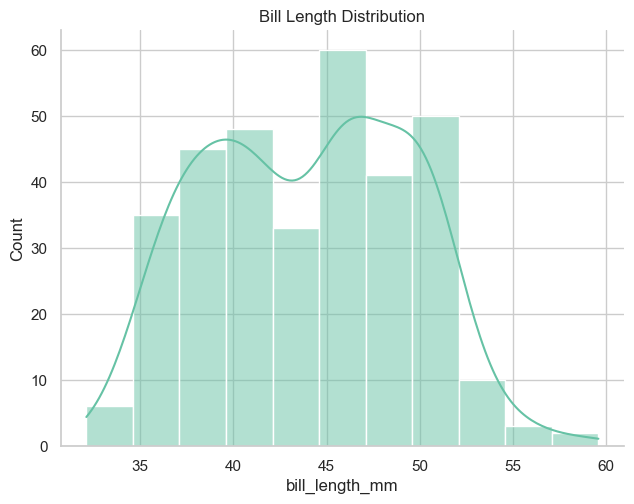

In [5]:
# Individual variable distributions
g1 = sns.displot(data=penguins, x='bill_length_mm', kde=True, height=5, aspect=1.3)
g1.set(title='Bill Length Distribution')

✓ Each species has different bill length!


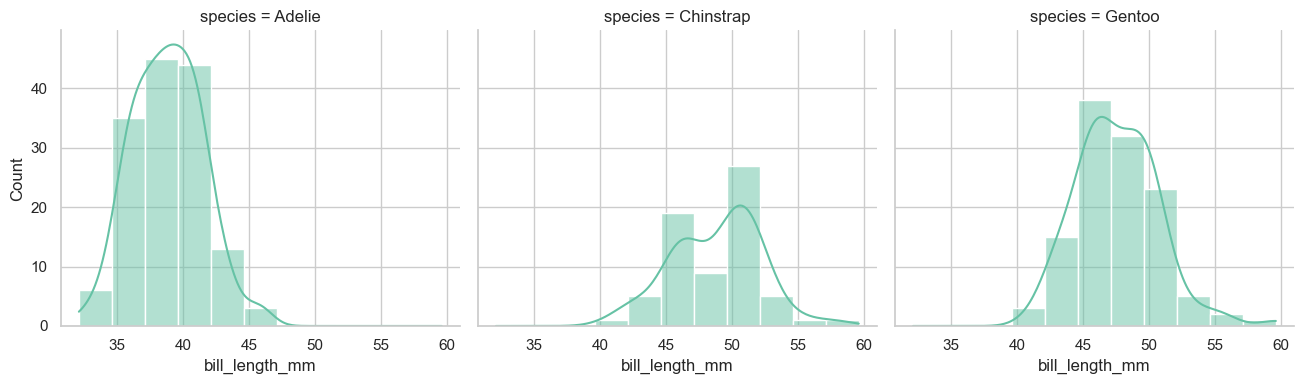

In [6]:
# By species
g2 = sns.displot(
    data=penguins,
    x='bill_length_mm',
    col='species',
    kde=True,
    height=4,
    aspect=1.1
)
print('✓ Each species has different bill length!')

## Step 2: Bivariate Analysis

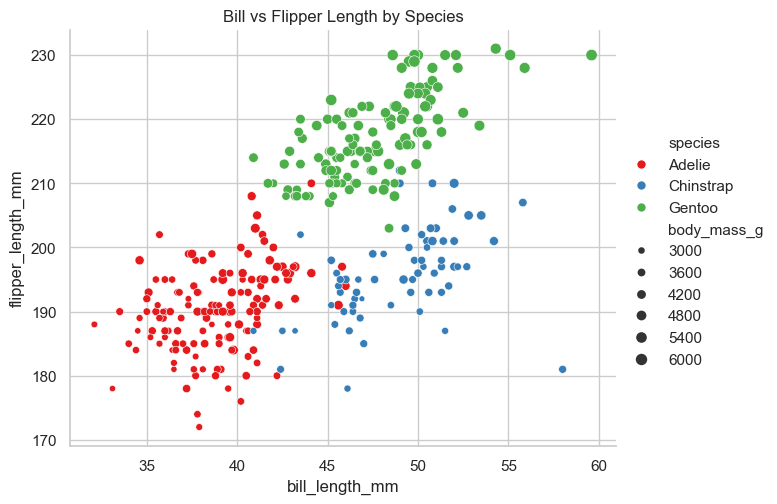

In [7]:
# Relationships between variables
g3 = sns.relplot(
    data=penguins,
    x='bill_length_mm',
    y='flipper_length_mm',
    hue='species',
    size='body_mass_g',
    height=5,
    aspect=1.3,
    palette='Set1'
)
g3.set(title='Bill vs Flipper Length by Species')


✓ Gentoo penguins are heavier!


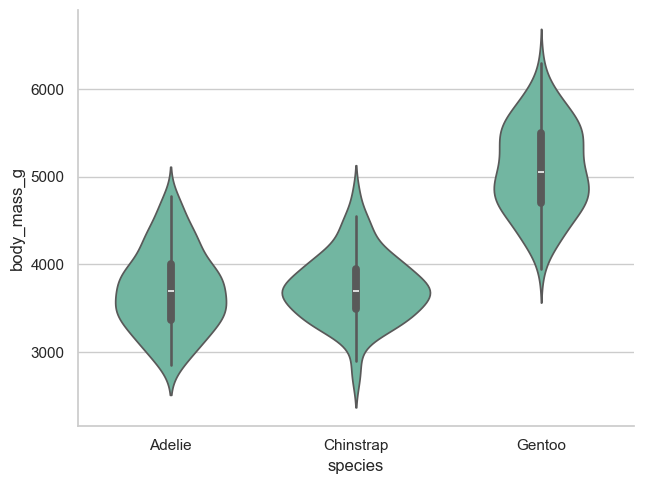

In [8]:
# Mass distribution by species
g4 = sns.catplot(
    data=penguins,
    x='species',
    y='body_mass_g',
    kind='violin',
    height=5,
    aspect=1.3
)
print('✓ Gentoo penguins are heavier!')

## Step 3: Multivariate Analysis

✓ Three species clearly separated in measurement space!


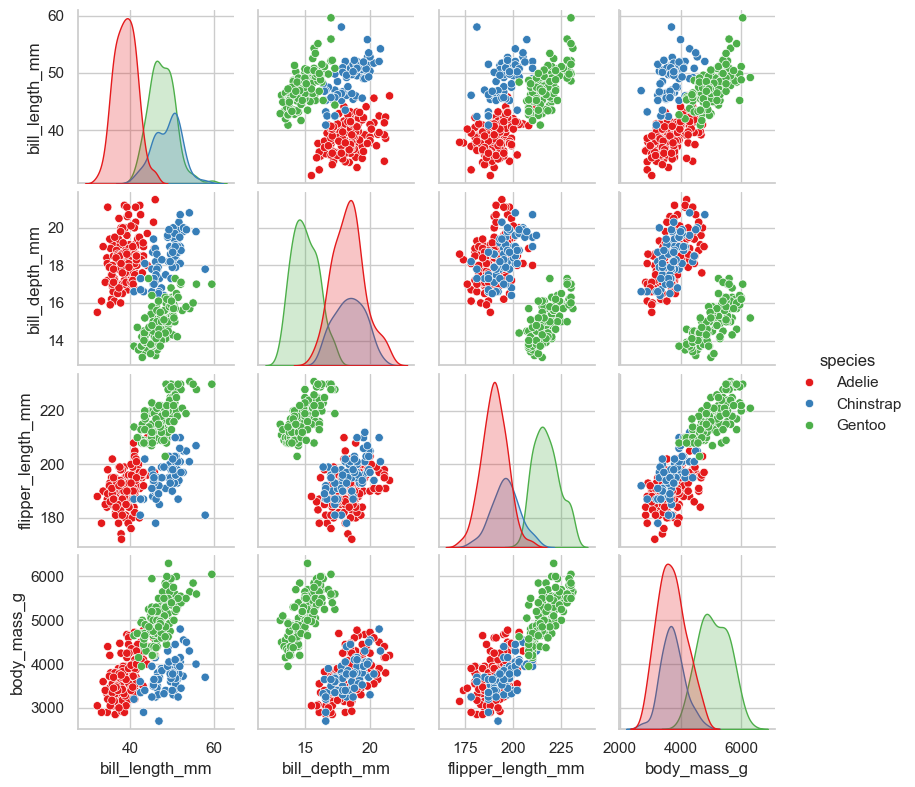

In [9]:
# PairPlot - see ALL relationships at once!
g5 = sns.pairplot(
    data=penguins,
    hue='species',
    palette='Set1',
    diag_kind='kde',
    height=2,
    aspect=1
)
print('✓ Three species clearly separated in measurement space!')

## Step 4: Correlation Analysis

Correlations:
  Bill length ↔ Flipper length: 0.65 (strong!)
  Flipper length ↔ Body mass: 0.87 (very strong!)
  Bill length ↔ Bill depth: -0.23 (weak negative)


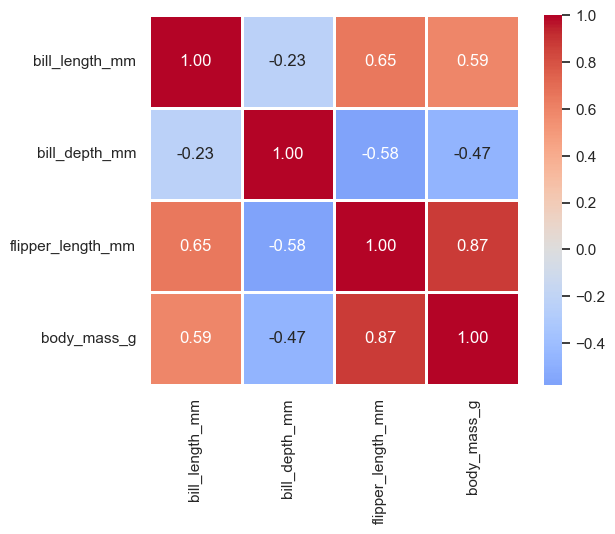

In [10]:
# Correlation heatmap
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
corr = penguins[numeric_cols].corr()

g6 = sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=2
)

print('Correlations:')
print(f'  Bill length ↔ Flipper length: {corr.loc["bill_length_mm", "flipper_length_mm"]:.2f} (strong!)')
print(f'  Flipper length ↔ Body mass: {corr.loc["flipper_length_mm", "body_mass_g"]:.2f} (very strong!)')
print(f'  Bill length ↔ Bill depth: {corr.loc["bill_length_mm", "bill_depth_mm"]:.2f} (weak negative)')